# DeePM: Regime-Robust Deep Portfolio Management

**Docker image**: `ml4t-gpu`

This notebook implements the DeePM framework (Wood, Roberts & Zohren 2026),
which trains an end-to-end portfolio policy that is robust across market regimes.
The key innovation is a SoftMin objective that penalizes poor performance in
any rolling window, not just on average.

**Learning Objectives**:
- Build a DeePM-style policy with FiLM conditioning, variable selection, and LSTM backbone
- Construct a macro graph prior from asset-class groupings
- Implement the SoftMin robust Sharpe objective
- Train with walk-forward validation and early stopping
- Compare the full DeePM against a no-SoftMin ablation and two non-deep baselines
  (equal weight, inverse volatility)
- Evaluate performance across crisis vs calm regimes

**Book Reference**: Chapter 17, §17.8 (Deep Learning for Portfolio Construction)

**Prerequisites**: `11_dl_portfolio_allocation` (differentiable Sharpe concept)

## 1. Setup

In [1]:
"""DeePM: regime-robust portfolio management with chronological evaluation."""

import warnings

warnings.filterwarnings("ignore")

In [2]:
import hashlib
import json
import os
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
from deepm.configs import FeatureConfig, ModelConfig, TrainingConfig
from deepm.dataset import DeepmWindowDataset, build_static_metadata
from deepm.features import build_feature_panel
from deepm.graph import adjacency_to_attn_mask, build_macro_adjacency
from deepm.inference import infer_risk_weights_rolling
from deepm.model import DeepmPolicy
from deepm.train import train_model
from IPython.display import display
from matplotlib.colors import ListedColormap
from matplotlib.ticker import PercentFormatter
from torch.utils.data import DataLoader

from data import load_etfs
from utils.paths import get_chapter_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [3]:
# Production defaults - Papermill overrides for CI testing
MAX_SYMBOLS = 0
MAX_ITERS = 500
SEQ_LEN = 84
D_MODEL = 64
SEED = 42
DEVICE = "auto"
# Cache-first defaults for expensive DeePM training.
USE_CACHED_CHECKPOINTS_IF_AVAILABLE = True
SAVE_CHECKPOINTS_TO_CACHE = True

In [4]:
OUTPUT_DIR = get_output_dir(17, "deepm_regime_robust")
OUTPUT_DIR.mkdir(exist_ok=True)
FULL_MODEL_CACHE_PATH = OUTPUT_DIR / "deepm_full_cache.pt"
NOSM_MODEL_CACHE_PATH = OUTPUT_DIR / "deepm_no_softmin_cache.pt"
CANONICAL_OUTPUT_DIR = get_chapter_dir(17) / "output" / "deepm_regime_robust"
CANONICAL_FULL_MODEL_CACHE_PATH = CANONICAL_OUTPUT_DIR / "deepm_full_cache.pt"
CANONICAL_NOSM_MODEL_CACHE_PATH = CANONICAL_OUTPUT_DIR / "deepm_no_softmin_cache.pt"

### Cache Search Order

DeePM maintains separate caches for the full model and the no-SoftMin
ablation, so cache resolution checks multiple candidate paths.

In [5]:
def iter_cache_candidates(*paths: Path):
    """Yield unique cache paths in priority order."""
    seen: set[Path] = set()
    for path in paths:
        resolved = path.resolve()
        if resolved not in seen:
            seen.add(resolved)
            yield path

### Checkpoint Compatibility

Reuse only checkpoints whose parameter keys and tensor shapes still match the
current architecture.

In [6]:
def state_dict_is_compatible(model, state_dict: dict) -> tuple[bool, str]:
    """Return whether a cached state dict matches the current model layout."""
    if not isinstance(state_dict, dict):
        return False, "cache payload has no valid state_dict"

    expected = model.state_dict()
    expected_keys = set(expected.keys())
    got_keys = set(state_dict.keys())
    if expected_keys != got_keys:
        missing = sorted(expected_keys - got_keys)
        extra = sorted(got_keys - expected_keys)
        parts = []
        if missing:
            parts.append(f"missing keys: {missing[:3]}")
        if extra:
            parts.append(f"unexpected keys: {extra[:3]}")
        return False, "; ".join(parts)

    mismatch = next(
        (
            f"{key} expected {tuple(expected_tensor.shape)} got "
            f"{tuple(cached_shape) if cached_shape is not None else None}"
            for key, expected_tensor in expected.items()
            if (cached_shape := getattr(state_dict[key], "shape", None)) != expected_tensor.shape
        ),
        None,
    )
    if mismatch:
        return False, f"shape mismatch ({mismatch})"

    return True, ""

### Cache Provenance

Shape compatibility is necessary but insufficient. Bind each checkpoint to the
exact feature panel, universe, split, architecture, and training configuration.

In [7]:
def stable_panel_hash(feature_panel) -> str:
    """Hash the complete ordered training panel and its labels."""
    digest = hashlib.sha256()
    digest.update(json.dumps(feature_panel.assets).encode())
    digest.update(np.asarray(feature_panel.dates.view("i8")).tobytes())
    for values in [
        feature_panel.x,
        feature_panel.y_fwd1,
        feature_panel.vol_scale,
        feature_panel.mask,
    ]:
        array = np.ascontiguousarray(values)
        digest.update(str(array.dtype).encode())
        digest.update(json.dumps(array.shape).encode())
        digest.update(array.tobytes())
    return digest.hexdigest()

In [8]:
def expected_cache_provenance(model, training_cfg, variant: str) -> dict:
    """Return the exact identity required before loading a checkpoint."""
    return {
        "schema": "deepm-v2-unique-validation",
        "variant": variant,
        "panel_sha256": PANEL_SHA256,
        "universe": list(panel.assets),
        "train_end": str(train_end_date),
        "validation_end": str(val_end_date),
        "model": asdict(model_cfg),
        "training": asdict(training_cfg),
        "state_shapes": {key: tuple(value.shape) for key, value in model.state_dict().items()},
    }

In [9]:
IN_TEST_OUTPUT_MODE = (
    os.environ.get("ML4T_CHAPTER_OUTPUT_DIR") is not None or os.environ.get("ML4T_TEST_MODE") == "1"
)
USE_CACHED_CHECKPOINTS_IF_AVAILABLE = (
    os.environ.get("ML4T_ALLOW_MODEL_CACHE", str(int(USE_CACHED_CHECKPOINTS_IF_AVAILABLE))) == "1"
)
SAVE_CHECKPOINTS_TO_CACHE = (
    os.environ.get("ML4T_SAVE_MODEL_CACHE", str(int(SAVE_CHECKPOINTS_TO_CACHE))) == "1"
)
if IN_TEST_OUTPUT_MODE:
    cache_exists = any(
        path.exists()
        for path in iter_cache_candidates(
            FULL_MODEL_CACHE_PATH,
            CANONICAL_FULL_MODEL_CACHE_PATH,
            NOSM_MODEL_CACHE_PATH,
            CANONICAL_NOSM_MODEL_CACHE_PATH,
        )
    )
    if not cache_exists:
        MAX_ITERS = min(MAX_ITERS, 80)
        print(f"Bootstrap cache mode: MAX_ITERS reduced to {MAX_ITERS}")

if DEVICE == "auto":
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

set_global_seeds(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

Device: cuda


## 2. ETF Universe with Asset-Class Groups

DeePM uses a **macro graph prior**: assets within the same asset class attend
to each other, while cross-class attention is restricted. This embeds economic
structure into the model without requiring it to learn groupings from data.

In [10]:
US_EQUITY = ["SPY", "QQQ", "IWM", "VTV", "VUG", "MDY"]
INTL_EQUITY = ["EFA", "EEM", "VEA", "VWO"]
FIXED_INCOME = ["AGG", "TLT", "LQD", "HYG", "TIP", "SHY", "IEF"]
ALTERNATIVES = ["GLD", "SLV", "VNQ", "DBC"]
SECTORS = ["XLF", "XLE", "XLK", "XLV", "XLI", "XLU", "XLP", "XLY"]

In [11]:
# Asset universe with group labels
ASSET_GROUPS = {}
ASSET_GROUPS.update({symbol: "us_equity" for symbol in US_EQUITY})
ASSET_GROUPS.update({symbol: "intl_equity" for symbol in INTL_EQUITY})
ASSET_GROUPS.update({symbol: "fixed_income" for symbol in FIXED_INCOME})
ASSET_GROUPS.update({symbol: "alternatives" for symbol in ALTERNATIVES})
ASSET_GROUPS.update({symbol: "sectors" for symbol in SECTORS})

UNIVERSE = list(ASSET_GROUPS.keys())
if MAX_SYMBOLS > 0:
    UNIVERSE = UNIVERSE[:MAX_SYMBOLS]
    ASSET_GROUPS = {k: v for k, v in ASSET_GROUPS.items() if k in UNIVERSE}

N_ASSETS = len(UNIVERSE)
N_GROUPS = len(set(ASSET_GROUPS.values()))
print(f"Universe: {N_ASSETS} ETFs across {N_GROUPS} asset-class groups")

Universe: 29 ETFs across 5 asset-class groups


## 3. Load Prices and Build Feature Panel

DeePM features are computed from daily closes only:
- Volatility-normalized returns at multiple horizons
- Multi-scale MACD signals with re-normalization
- Log-price z-scores
- Robust clipping using rolling median and MAD

In [12]:
# Load ETFs (Polars at boundary, pandas for downstream)
etf_data = load_etfs()
etf_filtered = etf_data.filter(pl.col("symbol").is_in(UNIVERSE))

prices = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
)
prices = prices[[c for c in UNIVERSE if c in prices.columns]]
prices.index = pd.to_datetime(prices.index)

# Require 80% asset coverage per date
coverage_threshold = max(1, int(prices.shape[1] * 0.8))
prices = prices.dropna(thresh=coverage_threshold)
N_ASSETS = prices.shape[1]
UNIVERSE = list(prices.columns)
ASSET_GROUPS = {k: v for k, v in ASSET_GROUPS.items() if k in UNIVERSE}

print(f"Price panel: {prices.shape[0]} dates × {prices.shape[1]} assets")

Price panel: 5031 dates × 29 assets


In [13]:
feat_cfg = FeatureConfig(
    vol_span=63,
    ret_horizons=(1, 21, 63, 252),
    macd_pairs=((8, 24), (16, 48), (32, 96)),
    zscore_windows=(21, 252),
    clip_window=252,
    include_existence=True,
)

panel = build_feature_panel(prices, feat_cfg)
print(f"Feature panel: T={len(panel.dates)}, N={len(panel.assets)}, F={len(panel.feature_names)}")
print(f"Features: {panel.feature_names}")

Feature panel: T=5031, N=29, F=10
Features: ['ret_h1', 'ret_h21', 'ret_h63', 'ret_h252', 'macd_8_24', 'macd_16_48', 'macd_32_96', 'zscore_21', 'zscore_252', 'existence']


## 4. Macro Graph Prior

Assets are connected within their asset-class group (intra-group cliques).
We add cross-group edges for economically motivated relationships:
- US equity ↔ sectors (sectors are subsets of US equity)
- Fixed income ↔ alternatives (flight-to-quality linkage)

In [14]:
cross_edges = [
    ("us_equity", "sectors"),
    ("fixed_income", "alternatives"),
]

macro_graph = build_macro_adjacency(
    assets=panel.assets,
    asset_to_group=ASSET_GROUPS,
    cross_group_edges=cross_edges,
)

attn_mask = adjacency_to_attn_mask(macro_graph.adjacency)
attn_mask_tensor = torch.from_numpy(attn_mask)

print(f"Graph: {macro_graph.adjacency.sum()} edges (of {N_ASSETS**2} possible)")
print(f"Groups: {sorted(set(macro_graph.groups))}")

Graph: 333 edges (of 841 possible)
Groups: ['alternatives', 'fixed_income', 'intl_equity', 'sectors', 'us_equity']


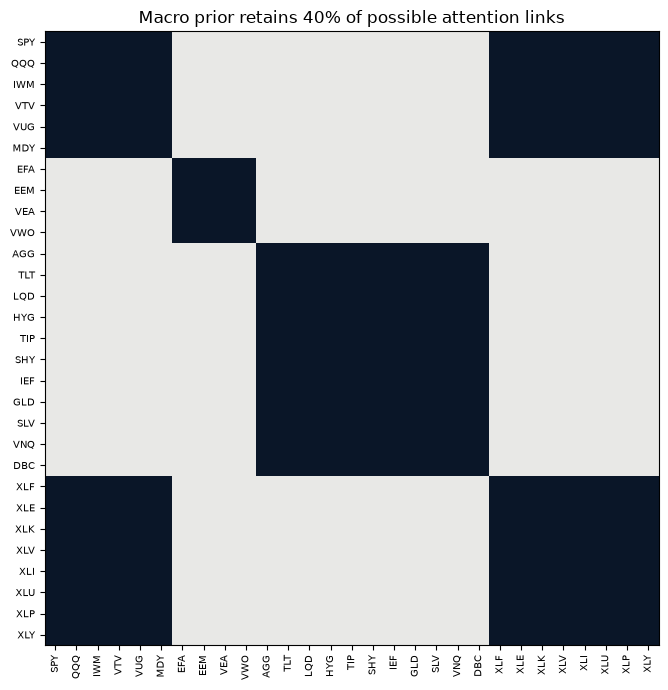

In [15]:
# Visualize adjacency matrix
fig, ax = plt.subplots(figsize=(8, 7))
graph_density = float(macro_graph.adjacency.mean())
im = ax.imshow(
    macro_graph.adjacency.astype(float),
    cmap=ListedColormap([COLORS["silver_muted"], COLORS["blue"]]),
    aspect="equal",
)
ax.set_xticks(range(N_ASSETS))
ax.set_xticklabels(panel.assets, rotation=90, fontsize=7)
ax.set_yticks(range(N_ASSETS))
ax.set_yticklabels(panel.assets, fontsize=7)
ax.set_title(f"Macro prior retains {graph_density:.0%} of possible attention links")
fig.tight_layout()
fig.show()

## 5. Train/Validation/Test Split and Datasets

In [16]:
dates = panel.dates
n_dates = len(dates)

train_end_date = dates[int(n_dates * 0.6)]
val_end_date = dates[int(n_dates * 0.8)]

print(f"Train: before {train_end_date:%Y-%m-%d}")
print(f"Val:   {train_end_date:%Y-%m-%d} to before {val_end_date:%Y-%m-%d}")
print(f"Test:  {val_end_date:%Y-%m-%d} to {dates[-1]:%Y-%m-%d}")

Train: before 2017-12-28
Val:   2017-12-28 to before 2021-12-28
Test:  2021-12-28 to 2025-12-31


In [17]:
train_ds = DeepmWindowDataset(panel, seq_len=SEQ_LEN, end_date=train_end_date)
val_ds = DeepmWindowDataset(
    panel, seq_len=SEQ_LEN, start_date=train_end_date, end_date=val_end_date
)
test_ds = DeepmWindowDataset(panel, seq_len=SEQ_LEN, start_date=val_end_date)

assert train_ds.start_indices[-1] + SEQ_LEN <= val_ds.start_indices[0]
assert val_ds.start_indices[-1] + SEQ_LEN <= test_ds.start_indices[0]

train_endpoints = train_ds.start_indices + SEQ_LEN - 1
val_endpoints = val_ds.start_indices + SEQ_LEN - 1
test_endpoints = test_ds.start_indices + SEQ_LEN - 1
assert dates[train_endpoints].max() < train_end_date
assert dates[val_endpoints].min() >= train_end_date
assert dates[val_endpoints].max() < val_end_date
assert dates[test_endpoints].min() >= val_end_date
assert dates[test_endpoints].max() < dates[-1]

print(f"Train windows: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
print(
    f"Unique validation endpoints: {len(val_endpoints)} "
    f"({dates[val_endpoints[0]]:%Y-%m-%d} to {dates[val_endpoints[-1]]:%Y-%m-%d})"
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

Train windows: 2935, Val: 923, Test: 923
Unique validation endpoints: 923 (2018-04-30 to 2021-12-27)


## 6. Static Metadata

Per-asset metadata for the context encoder: asset IDs, group IDs, and
estimated transaction costs.

In [18]:
# Rough cost estimates (bps one-way) by asset class
COST_BPS = {a: 5.0 for a in UNIVERSE}  # liquid ETFs: ~5 bps
for a in ["SLV", "DBC", "EEM", "VWO", "HYG", "EMB"]:
    if a in COST_BPS:
        COST_BPS[a] = 10.0  # less liquid: ~10 bps

static_meta = build_static_metadata(
    panel.assets,
    asset_to_group=ASSET_GROUPS,
    asset_to_cost_bps=COST_BPS,
)

print(f"Asset IDs: {static_meta.asset_ids.shape}")
print(f"Group IDs: {static_meta.group_ids.shape}")
print(f"Costs: {static_meta.costs.shape}")

Asset IDs: torch.Size([29])
Group IDs: torch.Size([29])
Costs: torch.Size([29, 1])


## 7. Model Configuration

We use a reduced-size model for this teaching notebook (`d_model=64` vs
the paper's 128). The architecture includes all DeePM components:
FiLM conditioning, V-VSN variable selection, LSTM backbone, cross-sectional
attention with Directed Delay, and macro graph attention.

In [19]:
model_cfg = ModelConfig(
    d_model=D_MODEL,
    n_heads=4,
    dropout=0.3,
    lstm_layers=1,
    temporal_mha_layers=1,
    cross_attention_heads=4,
    cross_attention_lag=1,
    macro_gnn_heads=4,
    asset_embedding_dim=16,
    group_embedding_dim=8,
    use_group_embedding=True,
    use_cost_in_context=True,
    vvsn_hidden_dim=64,
    adapter_hidden_mult=2,
)

model = DeepmPolicy(
    n_assets=N_ASSETS,
    n_features=len(panel.feature_names),
    n_groups=N_GROUPS,
    adjacency_mask=attn_mask_tensor,
    cfg=model_cfg,
)
model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"DeePM parameters: {n_params:,}")

DeePM parameters: 109,067


## 8. Training with SoftMin Robust Objective

The key loss function maximizes pooled Sharpe while penalizing the worst-case
rolling-window Sharpe via SoftMin:

$$\mathcal{L}(\theta) = -\text{SR}_{\text{pool}} - \lambda \cdot \text{SoftMin}_\tau(\{SR_b\})$$

This learns regime robustness without explicitly detecting or labeling regimes.

In [20]:
def save_training_cache(cache_path, state_dict, history_obj, provenance):
    """Persist best state plus lightweight diagnostics for cache-first reruns."""
    torch.save(
        {
            "best_state": state_dict,
            "history": {
                "steps": list(history_obj.steps),
                "train_objective": list(history_obj.train_objective),
                "train_sharpe_pool": list(history_obj.train_sharpe_pool),
                "val_sharpe_pool": list(history_obj.val_sharpe_pool),
            },
            "provenance": provenance,
        },
        cache_path,
    )

In [21]:
train_cfg = TrainingConfig(
    seq_len=SEQ_LEN,
    burn_in=21,
    batch_size=32,
    learning_rate=1e-4,
    weight_decay=1e-4,
    max_grad_norm=1.0,
    gamma_cost=0.5,
    softmin_tau=0.2,
    softmin_lambda=0.1,
    max_iters=MAX_ITERS,
    eval_every=25,
    metric_ema_alpha=0.45,
    metric_min_delta=0.001,
    early_stopping_patience=50,
    early_stopping_burn_in_iters=50,
    device=DEVICE,
)

print(f"Training for up to {MAX_ITERS} iterations...")
print(f"SoftMin: tau={train_cfg.softmin_tau}, lambda={train_cfg.softmin_lambda}")

Training for up to 500 iterations...
SoftMin: tau=0.2, lambda=0.1


In [22]:
PANEL_SHA256 = stable_panel_hash(panel)
full_cache_provenance = expected_cache_provenance(model, train_cfg, "full")
print(f"Training panel SHA-256: {PANEL_SHA256[:16]}...")

Training panel SHA-256: 33ff115fae3b23f9...


In [23]:
best_state = None
history = None
history_steps = []
history_train_objective = []
history_train_sharpe = []
history_val_sharpe = []

if USE_CACHED_CHECKPOINTS_IF_AVAILABLE:
    for cache_path in iter_cache_candidates(FULL_MODEL_CACHE_PATH, CANONICAL_FULL_MODEL_CACHE_PATH):
        if not cache_path.exists():
            continue
        cache_payload = torch.load(cache_path, map_location="cpu")
        if isinstance(cache_payload, dict) and "best_state" in cache_payload:
            if cache_payload.get("provenance") != full_cache_provenance:
                print(f"Skipping wrong-provenance full-model cache at {cache_path}")
                continue
            candidate_state = cache_payload["best_state"]
            is_compatible, reason = state_dict_is_compatible(model, candidate_state)
            if not is_compatible:
                print(f"Skipping incompatible full-model cache at {cache_path}: {reason}")
                continue
            best_state = candidate_state
            history_payload = cache_payload.get("history", {})
            history_steps = list(history_payload.get("steps", []))
            history_train_objective = list(history_payload.get("train_objective", []))
            history_train_sharpe = list(history_payload.get("train_sharpe_pool", []))
            history_val_sharpe = list(history_payload.get("val_sharpe_pool", []))
            print(f"Loaded full DeePM checkpoint from {cache_path}")
            break

In [24]:
if best_state is None:
    best_state, history = train_model(
        model,
        train_loader=train_loader,
        val_loader=val_loader,
        static_meta=static_meta,
        cfg=train_cfg,
    )

    history_steps = list(history.steps)
    history_train_objective = list(history.train_objective)
    history_train_sharpe = list(history.train_sharpe_pool)
    history_val_sharpe = list(history.val_sharpe_pool)

    print(f"\nTraining complete: {len(history_steps)} eval points")
    if not best_state:
        print("WARNING: No valid checkpoint saved, using final model state")
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    elif history_val_sharpe:
        valid_sharpes = [s for s in history_val_sharpe if not np.isnan(s)]
        if valid_sharpes:
            print(f"Best validation Sharpe: {max(valid_sharpes):.3f}")


Training complete: 20 eval points
Best validation Sharpe: 1.590


In [25]:
if SAVE_CHECKPOINTS_TO_CACHE and best_state and history is not None:
    save_training_cache(FULL_MODEL_CACHE_PATH, best_state, history, full_cache_provenance)
    print(f"Saved full DeePM checkpoint cache to {FULL_MODEL_CACHE_PATH}")

### Training Diagnostics

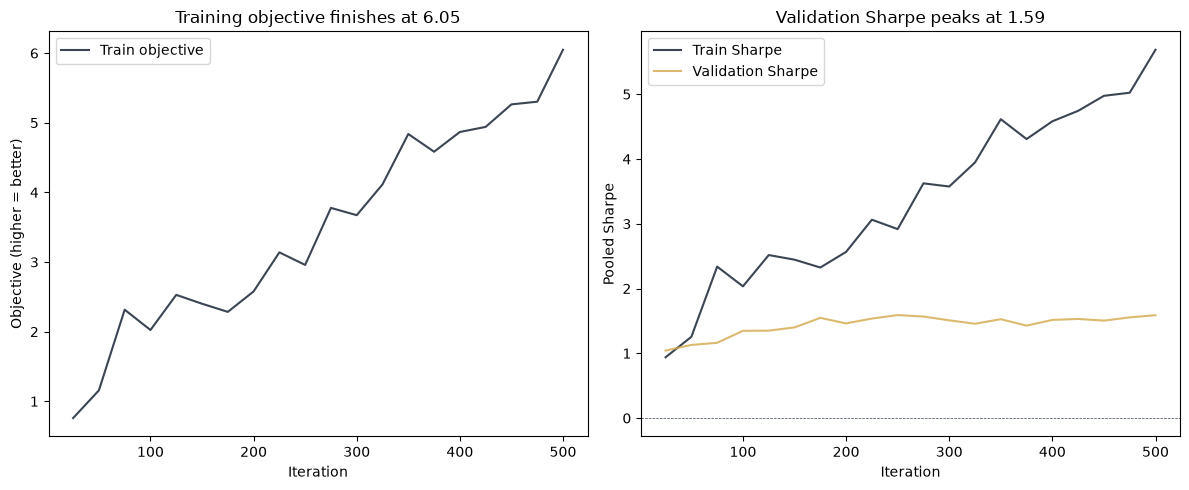

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(
    history_steps,
    history_train_objective,
    label="Train objective",
    color=COLORS["blue"],
    alpha=0.8,
)
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective (higher = better)")
final_training_objective = history_train_objective[-1] if history_train_objective else float("nan")
ax.set_title(f"Training objective finishes at {final_training_objective:.2f}")
ax.legend()

ax = axes[1]
ax.plot(
    history_steps,
    history_train_sharpe,
    label="Train Sharpe",
    color=COLORS["blue"],
    alpha=0.8,
)
ax.plot(
    history_steps,
    history_val_sharpe,
    label="Validation Sharpe",
    color=COLORS["amber"],
    alpha=0.8,
)
ax.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Pooled Sharpe")
best_training_val = max(history_val_sharpe) if history_val_sharpe else float("nan")
ax.set_title(f"Validation Sharpe peaks at {best_training_val:.2f}")
ax.legend()

fig.tight_layout()
fig.show()

**Finding**: Cache-first execution preserves expensive DeePM training checkpoints and keeps
reruns focused on evaluation and diagnostics unless explicit retraining is required.

## 9. Ablation Study

We isolate the contribution of the SoftMin penalty with a single architectural
ablation, then compare both DeePM configurations against two non-deep baselines:

1. **Full DeePM** - SoftMin + macro graph + all components
2. **No SoftMin** - Same architecture but trained with plain Sharpe loss ($\lambda = 0$)
3. **Equal Weight** - $w_i = 1/N$, daily rebalanced
4. **Inverse Volatility** - $w_i \propto 1/\sigma_i^{21d}$, daily rebalanced

Per-component ablations within the DeePM architecture (FiLM, V-VSN, Directed Delay)
are not run here; the chapter cites Wood, Roberts & Zohren (2026) for those.

### Train the No-SoftMin ablation

In [27]:
model_no_softmin = DeepmPolicy(
    n_assets=N_ASSETS,
    n_features=len(panel.feature_names),
    n_groups=N_GROUPS,
    adjacency_mask=attn_mask_tensor,
    cfg=model_cfg,
)
model_no_softmin.to(DEVICE)

nosm_cfg = TrainingConfig(
    seq_len=SEQ_LEN,
    burn_in=21,
    batch_size=32,
    learning_rate=1e-4,
    weight_decay=1e-4,
    max_grad_norm=1.0,
    gamma_cost=0.5,
    softmin_tau=0.2,
    softmin_lambda=0.0,  # No SoftMin penalty
    max_iters=MAX_ITERS,
    eval_every=25,
    early_stopping_patience=50,
    early_stopping_burn_in_iters=50,
    device=DEVICE,
)

In [28]:
nosm_cache_provenance = expected_cache_provenance(model_no_softmin, nosm_cfg, "no-softmin")

In [29]:
print("Training No-SoftMin ablation...")
best_state_nosm = None
history_nosm = None

if USE_CACHED_CHECKPOINTS_IF_AVAILABLE:
    for cache_path in iter_cache_candidates(NOSM_MODEL_CACHE_PATH, CANONICAL_NOSM_MODEL_CACHE_PATH):
        if not cache_path.exists():
            continue
        cache_payload_nosm = torch.load(cache_path, map_location="cpu")
        if isinstance(cache_payload_nosm, dict) and "best_state" in cache_payload_nosm:
            if cache_payload_nosm.get("provenance") != nosm_cache_provenance:
                print(f"Skipping wrong-provenance no-SoftMin cache at {cache_path}")
                continue
            candidate_state_nosm = cache_payload_nosm["best_state"]
            is_compatible, reason = state_dict_is_compatible(model_no_softmin, candidate_state_nosm)
            if not is_compatible:
                print(f"Skipping incompatible no-SoftMin cache at {cache_path}: {reason}")
                continue
            best_state_nosm = candidate_state_nosm
            print(f"Loaded no-SoftMin checkpoint from {cache_path}")
            break

Training No-SoftMin ablation...


In [30]:
if best_state_nosm is None:
    best_state_nosm, history_nosm = train_model(
        model_no_softmin,
        train_loader=train_loader,
        val_loader=val_loader,
        static_meta=static_meta,
        cfg=nosm_cfg,
    )

    if not best_state_nosm:
        print("WARNING: No valid checkpoint, using final model state")
        best_state_nosm = {
            k: v.detach().cpu().clone() for k, v in model_no_softmin.state_dict().items()
        }

In [31]:
if SAVE_CHECKPOINTS_TO_CACHE and best_state_nosm and history_nosm is not None:
    save_training_cache(
        NOSM_MODEL_CACHE_PATH,
        best_state_nosm,
        history_nosm,
        nosm_cache_provenance,
    )
    print(f"Saved no-SoftMin checkpoint cache to {NOSM_MODEL_CACHE_PATH}")

### Compute Test-Period Returns for All Models

In [32]:
# Load best states
model.load_state_dict(best_state)
model_no_softmin.load_state_dict(best_state_nosm)

# Rolling-window inference on the full panel (test period extracted later)
risk_signals_deepm = infer_risk_weights_rolling(
    model,
    panel,
    static_meta=static_meta,
    seq_len=SEQ_LEN,
    batch_size=256,
    device=DEVICE,
)

risk_signals_nosm = infer_risk_weights_rolling(
    model_no_softmin,
    panel,
    static_meta=static_meta,
    seq_len=SEQ_LEN,
    batch_size=256,
    device=DEVICE,
)

### Compute Net Returns and Baselines

In [33]:
# Forward raw returns
raw_returns = prices.pct_change(fill_method=None).shift(-1)

# Convert policy outputs to the volatility-scaled target weights used by the loss.
vol_scale = pd.DataFrame(panel.vol_scale, index=panel.dates, columns=panel.assets)
risk_weights_deepm = risk_signals_deepm * vol_scale
risk_weights_nosm = risk_signals_nosm * vol_scale

# Test period mask
test_start = val_end_date
test_mask = (raw_returns.index >= test_start) & (raw_returns.index < raw_returns.index[-1])

### Common Net-Return Function

Normalize each target-weight vector, apply its forward return, and charge the same
per-asset one-way cost schedule to every allocator.

In [34]:
# DeePM returns (risk-weighted, equal-weighted across assets)
def portfolio_returns_from_weights(weights_df, returns_df, mask, cost_bps):
    """Compute net returns from target weights and per-asset one-way costs."""
    w = weights_df.loc[mask]
    r = returns_df.loc[mask]
    # Align columns
    common = w.columns.intersection(r.columns)
    w, r = w[common], r[common]
    w = w.where(r.notna(), 0.0).fillna(0.0)
    r = r.fillna(0.0)
    # Normalize weights per timestep (absolute values sum to 1)
    w_abs = w.abs()
    w_norm = w.div(w_abs.sum(axis=1).clip(lower=1e-8), axis=0)
    gross = (w_norm * r).sum(axis=1)
    prior = w_norm.shift(1).fillna(0.0)
    turnover = (w_norm - prior).abs()
    cost_rates = pd.Series(cost_bps, dtype=float).reindex(common).fillna(0.0) / 10_000.0
    costs = turnover.mul(cost_rates, axis=1).sum(axis=1)
    return gross - costs

### Held-Out Allocator Returns

Apply the common function to both learned policies and both heuristic baselines.

In [35]:
deepm_returns = portfolio_returns_from_weights(risk_weights_deepm, raw_returns, test_mask, COST_BPS)
nosm_returns = portfolio_returns_from_weights(risk_weights_nosm, raw_returns, test_mask, COST_BPS)

# Equal weight baseline
ew_weights = pd.DataFrame(
    1.0 / len(raw_returns.columns), index=raw_returns.index, columns=raw_returns.columns
)
ew_returns = portfolio_returns_from_weights(ew_weights, raw_returns, test_mask, COST_BPS)
ew_returns.name = "EqualWeight"

# Inverse volatility baseline
vol_21 = prices.pct_change().rolling(21, min_periods=5).std()
inv_vol = 1.0 / vol_21.clip(lower=1e-6)
iv_weights = inv_vol.div(inv_vol.sum(axis=1), axis=0)
iv_returns = portfolio_returns_from_weights(iv_weights, raw_returns, test_mask, COST_BPS)
iv_returns.name = "InvVol"

## 10. Performance Comparison

In [36]:
def compute_perf_metrics(r, name):
    """Performance metrics from a return series."""
    r = r.dropna()
    if len(r) < 10:
        return {"Method": name, "Ann. Return": "N/A", "Sharpe": "N/A", "Max DD": "N/A"}
    mu = r.mean() * 252
    vol = r.std() * np.sqrt(252)
    sr = mu / (vol + 1e-8)
    cum = (1 + r).cumprod()
    dd = float((cum / cum.cummax() - 1).min())
    return {
        "Method": name,
        "Ann. Return": f"{mu:.1%}",
        "Ann. Vol": f"{vol:.1%}",
        "Sharpe": f"{sr:.2f}",
        "Max DD": f"{dd:.1%}",
    }


results = pd.DataFrame(
    [
        compute_perf_metrics(deepm_returns, "DeePM (full)"),
        compute_perf_metrics(nosm_returns, "DeePM (no SoftMin)"),
        compute_perf_metrics(ew_returns, "Equal Weight"),
        compute_perf_metrics(iv_returns, "Inverse Volatility"),
    ]
)
results

,Method,Ann. Return,Ann. Vol,Sharpe,Max DD
0,DeePM (full),2.7%,4.8%,0.56,-7.3%
1,DeePM (no SoftMin),2.4%,5.2%,0.47,-9.1%
2,Equal Weight,8.3%,12.0%,0.69,-18.4%
3,Inverse Volatility,5.0%,8.0%,0.63,-15.0%


**Finding**: The table is the primary held-out comparison. Validation checkpointing uses
one chronological endpoint per window, and held-out evaluation uses each date once. Because
this is one seeded
SoftMin-vs-no-SoftMin ablation, the observed gap is evidence for this run rather than a
population estimate of the SoftMin effect.

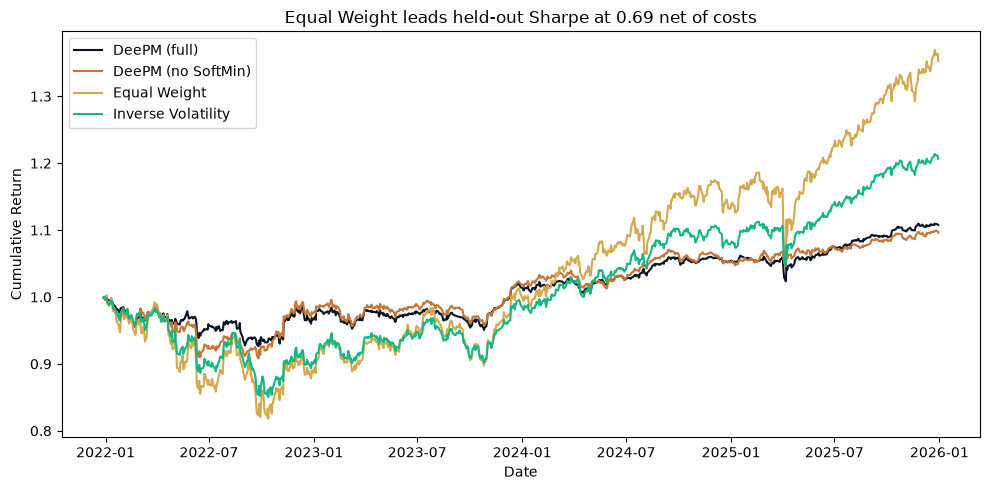

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
method_returns = {
    "DeePM (full)": deepm_returns,
    "DeePM (no SoftMin)": nosm_returns,
    "Equal Weight": ew_returns,
    "Inverse Volatility": iv_returns,
}
method_colors = {
    "DeePM (full)": COLORS["blue"],
    "DeePM (no SoftMin)": COLORS["copper"],
    "Equal Weight": COLORS["amber"],
    "Inverse Volatility": COLORS["positive"],
}
sharpe_by_method = {
    name: float(series.mean() / (series.std() + 1e-8) * np.sqrt(252))
    for name, series in method_returns.items()
}
for label, r in method_returns.items():
    cum = (1 + r.dropna()).cumprod()
    ax.plot(cum.index, cum.values, label=label, color=method_colors[label])

winner = max(sharpe_by_method, key=sharpe_by_method.get)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.set_title(f"{winner} leads held-out Sharpe at {sharpe_by_method[winner]:.2f} net of costs")
ax.legend()
fig.tight_layout()
fig.show()

**Trading implication**: Read terminal wealth together with Sharpe and drawdown. A
single seeded path can motivate a robustness hypothesis, but it cannot establish that
the SoftMin term will dominate across seeds or market samples.

## 11. Regime-Sliced Evaluation

The SoftMin objective aims to reduce the gap between crisis and calm performance.
We split the test period by realized volatility to evaluate regime robustness.

In [38]:
# Use rolling 21d realized volatility of SPY as regime indicator
spy_vol = prices["SPY"].pct_change().rolling(21).std() * np.sqrt(252)
spy_vol_test = spy_vol.loc[test_mask].dropna()
vol_median = spy_vol_test.median()

calm_mask = spy_vol_test <= vol_median
crisis_mask = spy_vol_test > vol_median

print(f"Regime split: {calm_mask.sum()} calm days, {crisis_mask.sum()} crisis days")
print(f"Volatility threshold (SPY 21d annualized): {vol_median:.1%}")


def regime_sharpe(r, mask):
    """Annualized Sharpe on masked days."""
    rm = r.reindex(mask.index)[mask]
    if len(rm) < 10:
        return float("nan")
    return float(rm.mean() / (rm.std() + 1e-8) * np.sqrt(252))


regime_results = pd.DataFrame(
    [
        {
            "Method": name,
            "Calm Sharpe": f"{regime_sharpe(r, calm_mask):.2f}",
            "Crisis Sharpe": f"{regime_sharpe(r, crisis_mask):.2f}",
            "Gap": f"{regime_sharpe(r, calm_mask) - regime_sharpe(r, crisis_mask):.2f}",
        }
        for name, r in method_returns.items()
    ]
)
regime_results

Regime split: 503 calm days, 503 crisis days
Volatility threshold (SPY 21d annualized): 14.0%


,Method,Calm Sharpe,Crisis Sharpe,Gap
0,DeePM (full),0.92,0.41,0.51
1,DeePM (no SoftMin),1.06,0.19,0.87
2,Equal Weight,0.93,0.60,0.33
3,Inverse Volatility,0.92,0.47,0.46


**Finding**: The calm-versus-crisis gap is the direct diagnostic. A smaller gap in
this seeded run is consistent with the SoftMin objective, but attribution requires
replication across seeds and samples.

## 12. Drawdown Analysis

### Drawdown Helper

Convert a return series into a drawdown series (peak-to-trough ratio minus one).

In [39]:
def _drawdown_series(r):
    cum = (1 + r.dropna()).cumprod()
    return cum / cum.cummax() - 1

### Persist Drawdown Panel

Persist the figure source data so the book-repo publication script
(`~/ml4t/book/17_portfolio_construction/figures/scripts/generate_figure_17_9_deepm_drawdowns.py`)
can render figure 17.9 without re-running this notebook.

In [40]:
dd_deepm = _drawdown_series(deepm_returns)
dd_nosm = _drawdown_series(nosm_returns)
dd_ew = _drawdown_series(ew_returns)

drawdowns_index = dd_deepm.index.union(dd_nosm.index).union(dd_ew.index).union(spy_vol_test.index)
drawdowns_panel = pd.DataFrame(
    {
        "deepm_full_dd": dd_deepm.reindex(drawdowns_index),
        "no_softmin_dd": dd_nosm.reindex(drawdowns_index),
        "equal_weight_dd": dd_ew.reindex(drawdowns_index),
        "spy_vol_21d_ann": spy_vol_test.reindex(drawdowns_index),
    },
    index=drawdowns_index,
)
drawdowns_panel.index.name = "timestamp"
drawdowns_panel = drawdowns_panel.reset_index()
drawdowns_panel["vol_median"] = float(vol_median)
pl.from_pandas(drawdowns_panel).write_parquet(OUTPUT_DIR / "drawdowns.parquet")

### Drawdown and Volatility Plot

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
plt.close(fig)

ax = axes[0]
for dd, label, linestyle, linewidth in [
    (dd_deepm, "DeePM (full)", "-", 1.6),
    (dd_nosm, "DeePM (no SoftMin)", "--", 1.4),
    (dd_ew, "Equal Weight", ":", 1.6),
]:
    ax.plot(
        dd.index,
        dd.values,
        label=label,
        color=method_colors[label],
        linestyle=linestyle,
        linewidth=linewidth,
    )
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.set_ylabel("Drawdown")
ax.set_title(f"Full DeePM max drawdown {dd_deepm.min():.1%} vs {dd_nosm.min():.1%} without SoftMin")
ax.legend()

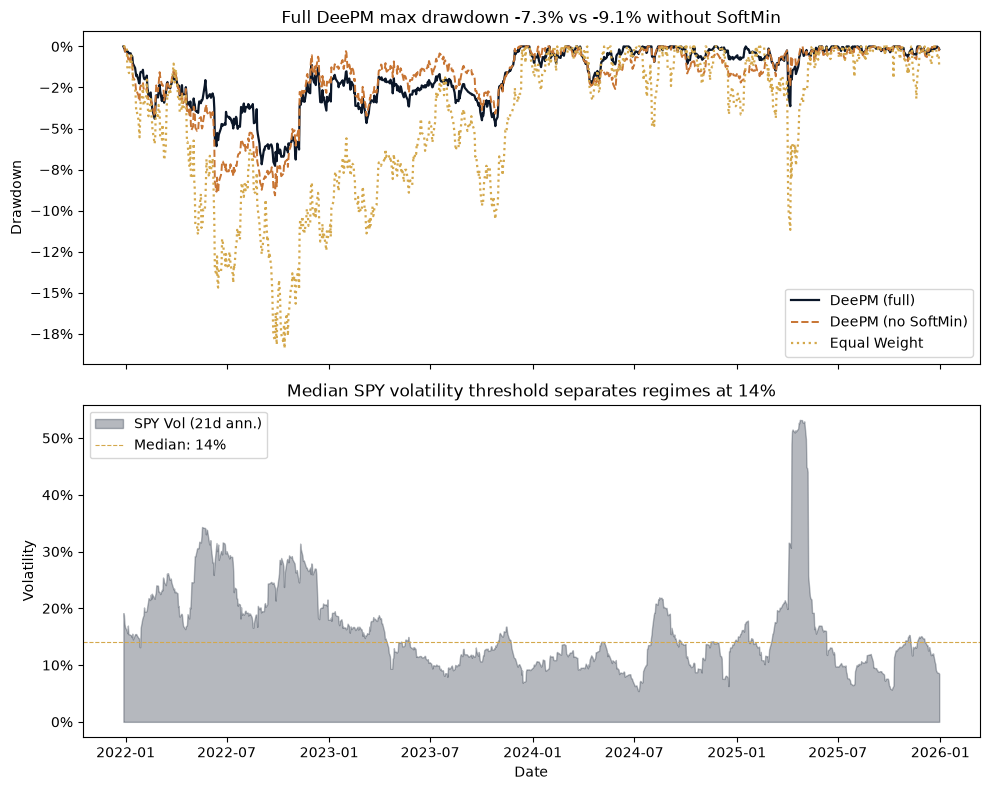

In [42]:
ax = axes[1]
ax.fill_between(
    spy_vol_test.index,
    0,
    spy_vol_test.values,
    color=COLORS["blue"],
    alpha=0.3,
    label="SPY Vol (21d ann.)",
)
ax.axhline(
    vol_median,
    color=COLORS["amber"],
    linestyle="--",
    linewidth=0.8,
    label=f"Median: {vol_median:.0%}",
)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.set_ylabel("Volatility")
ax.set_xlabel("Date")
ax.set_title(f"Median SPY volatility threshold separates regimes at {vol_median:.0%}")
ax.legend()

fig.tight_layout()
display(fig)

**Trading implication**: Drawdown shape matters as much as terminal Sharpe when allocator
capacity is constrained by investor tolerance and risk budgets.

## Key Takeaways

1. **SoftMin targets the weak-window path**: compare the full and no-SoftMin rows
   in both the held-out and regime-sliced tables. This single seeded ablation is a
   diagnostic, not an estimate of the effect across seeds.
2. **Macro graph prior constrains cross-asset attention** to within-asset-class
   and economically motivated cross-class edges. This embeds structure into the
   model rather than asking it to recover groupings from data; whether that prior
   is binding versus a fully learnable attention matrix is not tested here.
3. **Cost awareness enters training as a differentiable turnover penalty**
   ($\gamma_{\text{cost}}=0.5$ over the asset-specific cost schedule). Held-out
   evaluation then applies the full one-way basis-point schedule to normalized
   target-weight changes, including the initial entry trade.
4. **Component-level ablations are out of scope for this notebook**. The
   SoftMin-vs-no-SoftMin comparison isolates the regime-robustness mechanism;
   isolating FiLM, V-VSN, or Directed Delay individually would require additional
   training runs that this teaching notebook does not perform.

**Next**: `09_allocator_comparison` for side-by-side allocator comparisons under
identical signal inputs. The cross-case-study external-validity comparison lives in
Ch20 ([`05_portfolio_allocation`](../20_strategy_synthesis/05_portfolio_allocation.ipynb)).

**Book**: §17.8 discusses the DeePM framework in detail, including
the SoftMin robust objective and its connection to regime adaptation.